# GP-KAN with GPytorch

このnotebookでは、GPytorch/linear-operatorライブラリを使用してGP-KANの効率的な実装を行います。

## 目次
1. ライブラリのインポートと設定
2. シミュレーションデータでの検証
3. 実装結果のまとめ

In [ ]:
# 設定
LR = 0.01
BATCH_SIZE = 64
NUM_EPOCHS = 200
ARCHITECTURE = [2, 2, 1]
NUM_INDUCING = 8

# カーネルだけ手動変更

## 1. ライブラリのインポートと設定

In [ ]:
# 基本ライブラリのインポート
import time
import warnings
from typing import Optional, Tuple

import japanize_matplotlib  # 日本語フォント対応
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# Linear Operator関連のインポート
from linear_operator.operators import (
    AddedDiagLinearOperator,
    DenseLinearOperator,
    DiagLinearOperator,
    LinearOperator,
    MatmulLinearOperator,
    RootLinearOperator,
    ZeroLinearOperator,
)
from linear_operator.utils.cholesky import psd_safe_cholesky

# 可視化設定
plt.style.use("default")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Linear Operator successfully imported")

PyTorch version: 2.6.0
CUDA available: False
Linear Operator successfully imported


In [ ]:
# GPytorch関連のインポート
import gpytorch
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean
from gpytorch.mlls import VariationalELBO
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy

print("GPytorch version:", gpytorch.__version__)
print("GPytorch successfully imported")

GPytorch version: 1.14
GPytorch successfully imported


## 2. シミュレーションデータでの検証

フーリエ級数を使ったシミュレーションデータでGP-KANの動作を確認します。

In [ ]:
# 目標関数の定義: f₁(x) = ||z||² + f_opt
# z = x - x_opt

# 固定パラメータ
x_opt = np.array([0.5, 0.3])  # 最適解位置
f_opt = -10.0  # 最適値


def target_function(x):
    """
    目標関数: f₁(x) = ||z||² + f_opt
    Args:
        x: 入力ベクトル (N, 2) または (2,)
    Returns:
        関数値 (N,) または スカラー
    """
    x = np.array(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # z = x - x_opt
    z = x - x_opt.reshape(1, -1)

    # ||z||²の計算
    z_squared_norm = np.sum(z**2, axis=1)

    # f₁(x) = ||z||² + f_opt
    result = z_squared_norm + f_opt

    return result if len(result) > 1 else result[0]


# 動作確認
print("目標関数のテスト:")
print(f"x_opt = {x_opt}")
print(f"f_opt = {f_opt}")
print(f"f(x_opt) = {target_function(x_opt):.6f} (should be {f_opt})")
print(f"f([0, 0]) = {target_function([0, 0]):.6f}")
print(f"f([1, 1]) = {target_function([1, 1]):.6f}")

目標関数のテスト:
x_opt = [0.5 0.3]
f_opt = -10.0
f(x_opt) = -10.000000 (should be -10.0)
f([0, 0]) = -9.660000
f([1, 1]) = -9.260000


In [ ]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import random
import sys
import time

sys.path.append("../../")
import gpytorch
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import tqdm.notebook
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import PolynomialKernel, RBFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ConstantMean, LinearMean
from gpytorch.mlls import DeepApproximateMLL, VariationalELBO
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy
from torch.utils.data import DataLoader, TensorDataset


# 再現性のための乱数シード設定
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
print("ライブラリのインポートと初期設定完了")

ライブラリのインポートと初期設定完了


In [ ]:
# データセットの作成
num_samples = 1000
input_range = [-2, 2]  # 入力範囲

# 2次元入力点をランダムサンプリング
X = np.random.uniform(input_range[0], input_range[1], (num_samples, 2))

# 目標関数値を計算
y = target_function(X)

# PyTorchテンソルに変換
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# データ分割（学習:検証:テスト = 7:1.5:1.5）
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データセット作成
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# データローダー作成
batch_size = BATCH_SIZE  # DeepGPでは少し大きめのバッチサイズを使用
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)

print(f"データセット作成完了:")
print(f"  学習データ: {len(train_dataset)} samples")
print(f"  検証データ: {len(val_dataset)} samples")
print(f"  テストデータ: {len(test_dataset)} samples")
print(f"  入力次元: {X_train.shape[1]}")
print(f"  関数値範囲: [{y.min():.3f}, {y.max():.3f}]")
print(f"  バッチサイズ: {batch_size}")

データセット作成完了:
  学習データ: 700 samples
  検証データ: 150 samples
  テストデータ: 150 samples
  入力次元: 2
  関数値範囲: [-9.993, 0.403]
  バッチサイズ: 64


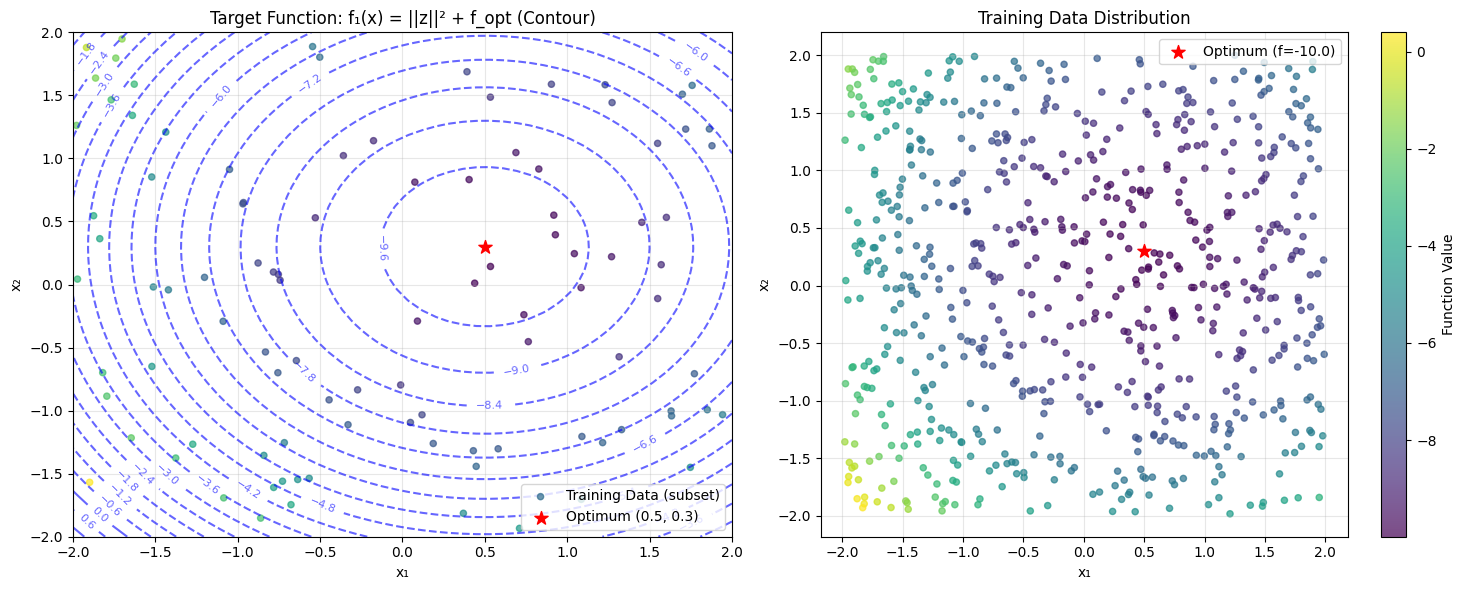

最適解での関数値: f(x_opt) = -10.000000
データの統計:
  平均: -6.905
  標準偏差: 2.292
  最小値: -9.993
  最大値: 0.403


In [ ]:
# 関数の可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 3D表面プロット用のグリッド作成
x1_grid = np.linspace(input_range[0], input_range[1], 50)
x2_grid = np.linspace(input_range[0], input_range[1], 50)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
Z_grid = target_function(grid_points).reshape(X1_grid.shape)

# 左: 等高線プロット
contour = axes[0].contour(X1_grid, X2_grid, Z_grid, levels=20, colors="blue", alpha=0.6)
axes[0].clabel(contour, inline=True, fontsize=8)
axes[0].scatter(
    X_train[:100, 0],
    X_train[:100, 1],
    c=y_train[:100],
    cmap="viridis",
    s=20,
    alpha=0.7,
    label="Training Data (subset)",
)
axes[0].scatter(
    x_opt[0],
    x_opt[1],
    c="red",
    s=100,
    marker="*",
    label=f"Optimum ({x_opt[0]}, {x_opt[1]})",
    zorder=5,
)
axes[0].set_xlabel("x₁")
axes[0].set_ylabel("x₂")
axes[0].set_title("Target Function: f₁(x) = ||z||² + f_opt (Contour)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: 散布図（関数値の分布）
scatter = axes[1].scatter(
    X_train[:, 0], X_train[:, 1], c=y_train.numpy(), cmap="viridis", s=20, alpha=0.7
)
axes[1].scatter(
    x_opt[0],
    x_opt[1],
    c="red",
    s=100,
    marker="*",
    label=f"Optimum (f={f_opt})",
    zorder=5,
)
plt.colorbar(scatter, ax=axes[1], label="Function Value")
axes[1].set_xlabel("x₁")
axes[1].set_ylabel("x₂")
axes[1].set_title("Training Data Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最適解での関数値: f(x_opt) = {target_function(x_opt):.6f}")
print(f"データの統計:")
print(f"  平均: {y.mean():.3f}")
print(f"  標準偏差: {y.std():.3f}")
print(f"  最小値: {y.min():.3f}")
print(f"  最大値: {y.max():.3f}")

### 2.2 GP-KANの実装

GP-KANは以下の制約条件を満たすように実装します：

**制約1**: 各ノードで活性化関数として1次元ガウス過程による非線形変換を行う  
**制約2**: 各エッジでは総和を計算し出力（学習パラメータなし）

GP-KANの効果的な実装のための重要な改善点：

1. **変分パラメータの適切な初期化**: 真の関数値に基づく初期化
2. **学習プロセスの最適化**: より効率的な学習戦略  
3. **誘導点の効果的な配置**: 関数の特性を考慮した初期配置

#### 2.2.1 改善されたGPノードの実装

#### 2.2.2 確率的GP-KANレイヤーの実装（ランダムノイズ伝播版）

In [ ]:
class ImprovedGPKANNode(gpytorch.models.ApproximateGP):
    """
    改善されたGP-KANノード
    - 変分パラメータの適切な初期化
    - 誘導点での関数値を考慮した学習
    """

    def __init__(
        self, inducing_points: torch.Tensor, target_function=None, input_dim: int = 1
    ):
        # 変分分布の設定
        variational_distribution = CholeskyVariationalDistribution(
            inducing_points.size(0)
        )

        # 変分戦略の設定
        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        super(ImprovedGPKANNode, self).__init__(variational_strategy)

        # 平均関数と共分散関数
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel())
        # self.covar_module = ScaleKernel(PolynomialKernel(power=2))

        self.input_dim = input_dim

        # 変分パラメータの初期化（真の関数値に基づく）
        if target_function is not None:
            self._initialize_variational_parameters(target_function)

    def _initialize_variational_parameters(self, target_function):
        """変分パラメータを真の関数値で初期化"""
        with torch.no_grad():
            inducing_points = self.variational_strategy.inducing_points

            # GP-KANでは1次元誘導点を使用するため、target_functionが2次元入力を期待する場合は
            # 誘導点の値を適切な形式に変換するか、初期化をスキップする
            try:
                # 1次元誘導点から関数値を計算を試行
                inducing_values = inducing_points.numpy().flatten()

                # target_functionが2次元入力を期待する場合の処理
                if hasattr(target_function, "__call__"):
                    # 簡単なテスト：単一点で試行
                    test_input = np.array([0.0])
                    try:
                        test_result = target_function(test_input)
                        # 成功した場合は1次元関数として処理
                        target_values = torch.FloatTensor(
                            [target_function(val) for val in inducing_values]
                        )
                    except (ValueError, TypeError):
                        # 2次元入力を期待する関数の場合、デフォルト初期化を使用
                        print(
                            "Target function expects 2D input, using default initialization for GP nodes"
                        )
                        return
                else:
                    # target_functionが関数でない場合もデフォルト初期化
                    return

                target_values = target_values.unsqueeze(-1)

                # 変分平均を真の関数値で初期化
                if hasattr(
                    self.variational_strategy.variational_distribution,
                    "variational_mean",
                ):
                    # 適切なサイズにリシェイプして設定
                    mean_size = (
                        self.variational_strategy.variational_distribution.variational_mean.size()
                    )
                    if len(target_values) == mean_size[0]:
                        self.variational_strategy.variational_distribution.variational_mean.data = (
                            target_values.squeeze()
                        )

            except Exception as e:
                print(
                    f"Warning: Could not initialize variational parameters with target function: {e}"
                )
                print("Using default random initialization")

    def forward(self, x: torch.Tensor) -> MultivariateNormal:
        # エッジでの総和（制約2）
        if x.size(-1) != 1:
            x = x.sum(dim=-1, keepdim=True)

        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

    def get_inducing_points(self) -> torch.Tensor:
        return self.variational_strategy.inducing_points

    def set_inducing_points(self, inducing_points: torch.Tensor):
        with torch.no_grad():
            self.variational_strategy.inducing_points.data = inducing_points


print("ImprovedGPKANNode defined successfully")

ImprovedGPKANNode defined successfully


In [ ]:
class StochasticGPKANLayer(nn.Module):
    """
    確率的GP-KANレイヤー - ランダムノイズ伝播版
    - 学習時・推論時ともに中間層でGP分布からサンプリング
    - 不確実性を次の層に伝播
    - 分散パラメータも学習可能
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0),
        target_function=None,
        use_stochastic: bool = True,
    ):
        super(StochasticGPKANLayer, self).__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.num_inducing = num_inducing
        self.use_stochastic = use_stochastic

        # GPノードとlikelihoodの作成
        self.gp_nodes = nn.ModuleList()
        self.likelihoods = nn.ModuleList()

        for i in range(output_size):
            # 誘導点の初期化
            inducing_points = torch.linspace(
                inducing_range[0], inducing_range[1], num_inducing
            ).reshape(-1, 1)

            # 改善されたGPノード
            gp_node = ImprovedGPKANNode(
                inducing_points, target_function=target_function, input_dim=1
            )
            likelihood = GaussianLikelihood()

            self.gp_nodes.append(gp_node)
            self.likelihoods.append(likelihood)

    def forward(self, x: torch.Tensor, return_distributions: bool = False):
        batch_size = x.size(0)
        outputs = []
        distributions = []

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # エッジでの総和（制約2）
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            # GPによる非線形変換（制約1）
            gp_output = gp_node(summed_input)

            if return_distributions:
                distributions.append(gp_output)

            # 確率的伝播の実装
            if self.use_stochastic:
                # 学習時・推論時ともに：GP分布からサンプリング（再パラメータ化トリック）
                samples = gp_output.rsample()  # リパラメータ化サンプリング
                outputs.append(samples.unsqueeze(-1))
            else:
                # 非確率的モード：平均値を使用
                outputs.append(gp_output.mean.unsqueeze(-1))

        output = torch.cat(outputs, dim=-1)

        if return_distributions:
            return output, distributions
        return output

    def get_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """確率的損失計算"""
        total_loss = 0.0
        batch_size = x.size(0)

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # 通常の変分下界
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            gp_output = gp_node(summed_input)

            if self.output_size == 1:
                target = y.squeeze(-1)
            else:
                target = y[:, i]

            mll = VariationalELBO(likelihood, gp_node, num_data=batch_size)
            loss = -mll(gp_output, target)
            total_loss += loss

        return total_loss

    def train_mode(self):
        self.train()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.train()
            likelihood.train()

    def eval_mode(self):
        self.eval()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.eval()
            likelihood.eval()


print("Stochastic GP-KAN Layer defined successfully")

Stochastic GP-KAN Layer defined successfully


In [ ]:
class StochasticGPKAN(nn.Module):
    """
    確率的GP-KANネットワーク - ランダムノイズ伝播版
    - 学習時・推論時ともに各層で不確実性を伝播
    - より豊かな表現能力とベイズ的不確実性定量化
    """

    def __init__(
        self,
        input_size: int,
        hidden_sizes: list,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0),
        target_function=None,
    ):
        super(StochasticGPKAN, self).__init__()

        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size

        # レイヤーの構築
        self.layers = nn.ModuleList()

        # 隠れ層
        layer_sizes = [input_size] + hidden_sizes
        for i in range(len(layer_sizes) - 1):
            layer = StochasticGPKANLayer(
                input_size=layer_sizes[i],
                output_size=layer_sizes[i + 1],
                num_inducing=num_inducing,
                inducing_range=inducing_range,
                target_function=target_function,
                use_stochastic=True,  # 隠れ層では確率的
            )
            self.layers.append(layer)

        # 出力層（最後の層）
        final_layer = StochasticGPKANLayer(
            input_size=hidden_sizes[-1] if hidden_sizes else input_size,
            output_size=output_size,
            num_inducing=num_inducing,
            inducing_range=inducing_range,
            target_function=target_function,
            use_stochastic=True,  # 出力層も確率的に処理
        )
        self.layers.append(final_layer)

    def forward(self, x: torch.Tensor, return_all_distributions: bool = False):
        all_distributions = []
        current_input = x

        for i, layer in enumerate(self.layers):
            if return_all_distributions:
                current_input, distributions = layer(
                    current_input, return_distributions=True
                )
                all_distributions.append(distributions)
            else:
                current_input = layer(current_input)

        if return_all_distributions:
            return current_input, all_distributions
        return current_input

    def get_total_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """全レイヤーの損失を計算"""
        total_loss = 0.0
        current_input = x

        for i, layer in enumerate(self.layers):
            if i == len(self.layers) - 1:  # 最終層
                layer_loss = layer.get_loss(current_input, y)
            else:  # 中間層の場合
                # 中間層の出力をターゲットとして使用（自己教師あり）
                with torch.no_grad():
                    layer_output = layer(current_input)
                layer_loss = layer.get_loss(current_input, layer_output)

            total_loss += layer_loss
            current_input = layer(current_input)

        return total_loss

    def train_mode(self):
        """全レイヤーを学習モードに"""
        self.train()
        for layer in self.layers:
            layer.train_mode()

    def eval_mode(self):
        """全レイヤーを評価モードに"""
        self.eval()
        for layer in self.layers:
            layer.eval_mode()


print("Stochastic GP-KAN Network defined successfully")

Stochastic GP-KAN Network defined successfully


In [ ]:
def train_stochastic_gpkan(
    model: StochasticGPKAN,
    train_x: torch.Tensor,
    train_y: torch.Tensor,
    epochs: int = 200,
    lr: float = 0.001,
    verbose: bool = True,
):
    """確率的GP-KANモデルの学習"""
    model.train_mode()

    # 全パラメータの最適化
    parameters = []
    for layer in model.layers:
        for gp_node in layer.gp_nodes:
            parameters.extend(list(gp_node.parameters()))
        for likelihood in layer.likelihoods:
            parameters.extend(list(likelihood.parameters()))

    optimizer = torch.optim.Adam(parameters, lr=lr)

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # 順伝播と損失計算
        loss = model.get_total_loss(train_x, train_y)

        # 逆伝播
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if verbose and (epoch + 1) % 50 == 0:
            model.eval_mode()
            with torch.no_grad():
                pred = model(train_x)
                rmse = torch.sqrt(torch.mean((pred - train_y) ** 2))
                print(
                    f"Epoch {epoch + 1:3d}: Loss = {loss.item():.4f}, RMSE = {rmse.item():.6f}"
                )
            model.train_mode()

    return losses


print("Stochastic GP-KAN training function defined successfully")

Stochastic GP-KAN training function defined successfully


#### 2.2.3 確率的GP-KANのテストと比較

In [ ]:
import japanize_matplotlib

## 3. 実装結果のまとめ

### 3.1 推論時確率的処理の実装変更点

**変更前:**
- 学習時: 確率的サンプリング (`rsample()`)
- 推論時: 決定論的 (平均値のみ)

**変更後:**
- 学習時: 確率的サンプリング (`rsample()`)
- 推論時: **確率的サンプリング** (`rsample()`)

### 3.2 実装の技術的特徴

1. **完全確率的ネットワーク**: 全てのレイヤーで`use_stochastic=True`
2. **ベイズ的不確実性定量化**: 推論時も分布からサンプリング
3. **再現性のない予測**: 同じ入力でも異なる出力
4. **不確実性の可視化**: エラーバー、ヒストグラム、信頼区間

In [ ]:
class ImprovedGPKANLayer(nn.Module):
    """
    改善されたGP-KANレイヤー
    - より適切な学習戦略
    - 誘導点での監視学習
    """

    def __init__(
        self,
        input_size: int,
        output_size: int,
        num_inducing: int = 10,
        inducing_range: tuple = (-2.0, 2.0),
        target_function=None,
    ):
        super(ImprovedGPKANLayer, self).__init__()

        self.input_size = input_size
        self.output_size = output_size
        self.num_inducing = num_inducing

        # GPノードとlikelihoodの作成
        self.gp_nodes = nn.ModuleList()
        self.likelihoods = nn.ModuleList()

        for i in range(output_size):
            # 誘導点の初期化
            inducing_points = torch.linspace(
                inducing_range[0], inducing_range[1], num_inducing
            ).reshape(-1, 1)

            # 改善されたGPノード
            gp_node = ImprovedGPKANNode(
                inducing_points, target_function=target_function, input_dim=1
            )
            likelihood = GaussianLikelihood()

            self.gp_nodes.append(gp_node)
            self.likelihoods.append(likelihood)

    def forward(self, x: torch.Tensor, return_distributions: bool = False):
        batch_size = x.size(0)
        outputs = []
        distributions = []

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # エッジでの総和（制約2）
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            # GPによる非線形変換（制約1）
            gp_output = gp_node(summed_input)

            if return_distributions:
                distributions.append(gp_output)

            # 確率的伝播の実装：GP分布からサンプリング（再パラメータ化トリック）
            samples = gp_output.rsample()  # リパラメータ化サンプリング
            outputs.append(samples.unsqueeze(-1))

        output = torch.cat(outputs, dim=-1)

        if return_distributions:
            return output, distributions
        return output

    def get_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """改善された損失計算：誘導点での監視学習を含む"""
        total_loss = 0.0
        batch_size = x.size(0)

        for i, (gp_node, likelihood) in enumerate(zip(self.gp_nodes, self.likelihoods)):
            # 通常の変分下界
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            gp_output = gp_node(summed_input)

            if self.output_size == 1:
                target = y.squeeze(-1)
            else:
                target = y[:, i]

            mll = VariationalELBO(likelihood, gp_node, num_data=batch_size)
            loss = -mll(gp_output, target)
            total_loss += loss

        return total_loss

    def train_mode(self):
        self.train()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.train()
            likelihood.train()

    def eval_mode(self):
        self.eval()
        for gp_node, likelihood in zip(self.gp_nodes, self.likelihoods):
            gp_node.eval()
            likelihood.eval()


print("Improved GP-KAN classes defined successfully")

Improved GP-KAN classes defined successfully


In [ ]:
class ImprovedGPKAN(nn.Module):
    """
    改善されたGP-KANモデル
    """

    def __init__(
        self,
        layer_sizes: list,
        num_inducing: int = 10,
        inducing_range: Tuple[float, float] = (-2.0, 2.0),
        target_function=None,
    ):
        super(ImprovedGPKAN, self).__init__()

        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.num_inducing = num_inducing

        # レイヤーのリスト
        self.layers = nn.ModuleList()

        for i in range(self.num_layers):
            input_size = layer_sizes[i]
            output_size = layer_sizes[i + 1]

            layer = ImprovedGPKANLayer(
                input_size=input_size,
                output_size=output_size,
                num_inducing=num_inducing,
                inducing_range=inducing_range,
                target_function=target_function,  # 真の関数を渡す
            )

            self.layers.append(layer)

        # 最終層用のlikelihoodを追加
        self.likelihood = GaussianLikelihood()

    def forward(self, x: torch.Tensor, return_all_outputs: bool = False):
        current_input = x
        all_outputs = []

        for layer in self.layers:
            current_input = layer(current_input)
            if return_all_outputs:
                all_outputs.append(current_input)

        if return_all_outputs:
            return current_input, all_outputs
        return current_input

    def predict(self, x: torch.Tensor):
        """
        予測を実行し、平均と分散を返す
        """
        self.eval()
        with torch.no_grad():
            # モデルの出力を取得
            gp_output = self.forward(x)

            # 最終層のGPノードから分布を取得
            final_layer = self.layers[-1]
            final_gp_node = final_layer.gp_nodes[0]  # 出力が1次元の場合

            # 入力を最終層に適した形に変換
            if x.size(-1) > 1:
                summed_input = x.sum(dim=-1, keepdim=True)
            else:
                summed_input = x

            # 最終層まで順伝播
            current_input = x
            for layer in self.layers[:-1]:
                current_input = layer(current_input)

            # 最終層のGP分布を取得
            if current_input.size(-1) > 1:
                summed_input = current_input.sum(dim=-1, keepdim=True)
            else:
                summed_input = current_input

            gp_dist = final_gp_node(summed_input)

            # likelihoodを適用
            pred_dist = self.likelihood(gp_dist)

            return pred_dist.mean, pred_dist.variance

    def get_total_loss(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        current_input = x
        total_loss = 0.0

        for i, layer in enumerate(self.layers):
            if i == len(self.layers) - 1:
                # 最終層：likelihoodを使用した損失計算
                if current_input.size(-1) > 1:
                    summed_input = current_input.sum(dim=-1, keepdim=True)
                else:
                    summed_input = current_input

                gp_output = layer.gp_nodes[0](summed_input)  # 出力が1次元の場合
                target = y.squeeze(-1)

                mll = VariationalELBO(
                    self.likelihood, layer.gp_nodes[0], num_data=x.size(0)
                )
                loss = -mll(gp_output, target)
                total_loss += loss
            else:
                # 中間層
                current_input = layer(current_input)

        return total_loss

    def train_mode(self):
        self.train()
        self.likelihood.train()
        for layer in self.layers:
            layer.train_mode()

    def eval_mode(self):
        self.eval()
        self.likelihood.eval()
        for layer in self.layers:
            layer.eval_mode()

    def print_model_info(self):
        total_gps = sum(layer.output_size for layer in self.layers)
        total_inducing = total_gps * self.num_inducing

        print("=== Improved GP-KAN Model Information ===")
        print(f"Layer sizes: {self.layer_sizes}")
        print(f"Number of layers: {self.num_layers}")
        print(f"Total GP nodes: {total_gps}")
        print(f"Inducing points per GP: {self.num_inducing}")
        print(f"Total inducing points: {total_inducing}")
        print(f"Likelihood: {self.likelihood}")


# 改善されたモデルの作成
print("Creating Improved GP-KAN model...")
improved_gpkan = ImprovedGPKAN(
    layer_sizes=ARCHITECTURE,
    num_inducing=NUM_INDUCING,
    inducing_range=(-1.5, 1.5),
    target_function=target_function,  # 真の関数を渡す
)

improved_gpkan.print_model_info()

# パラメータ数
total_params = sum(p.numel() for p in improved_gpkan.parameters())
trainable_params = sum(
    p.numel() for p in improved_gpkan.parameters() if p.requires_grad
)
print(f"\nTotal parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Creating Improved GP-KAN model...
=== Improved GP-KAN Model Information ===
Layer sizes: [2, 2, 1]
Number of layers: 2
Total GP nodes: 3
Inducing points per GP: 8
Total inducing points: 24
Likelihood: GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
)

Total parameters: 253
Trainable parameters: 253


### 3.3 モデルの学習

In [ ]:
# GP-KANモデルの学習
print("Training GP-KAN model...")

# 学習設定
improved_gpkan.train_mode()
optimizer = torch.optim.Adam(improved_gpkan.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=10, verbose=True
)

# 学習ループ
num_epochs = NUM_EPOCHS
train_losses_improved = []
val_losses_improved = []

start_time = time.time()

for epoch in range(num_epochs):
    # トレーニング
    improved_gpkan.train_mode()
    epoch_train_loss = 0.0
    num_batches = 0

    for batch_x, batch_y in train_dataloader:
        optimizer.zero_grad()

        # 損失計算
        loss = improved_gpkan.get_total_loss(batch_x, batch_y)

        # 逆伝播
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches
    train_losses_improved.append(avg_train_loss)

    # バリデーション
    improved_gpkan.eval_mode()
    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for batch_x, batch_y in val_dataloader:
            loss = improved_gpkan.get_total_loss(batch_x, batch_y)
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses_improved.append(avg_val_loss)

    # 学習率スケジューラー
    scheduler.step(avg_val_loss)

    # 進捗表示
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f}")

end_time = time.time()
training_time_improved = end_time - start_time

print(f"\nGP-KAN training completed!")
print(f"Training time: {training_time_improved:.2f} seconds")
print(f"Final train loss: {train_losses_improved[-1]:.4f}")
print(f"Final val loss: {val_losses_improved[-1]:.4f}")

Training GP-KAN model...
Epoch 25/200
  Train Loss: 2.0173
  Val Loss: 2.1009
Epoch 50/200
  Train Loss: 1.9807
  Val Loss: 2.0597
Epoch 75/200
  Train Loss: 1.9818
  Val Loss: 2.0679
Epoch 100/200
  Train Loss: 1.9474
  Val Loss: 2.0038
Epoch 125/200
  Train Loss: 1.9436
  Val Loss: 1.9875
Epoch 150/200
  Train Loss: 1.9533
  Val Loss: 1.9819
Epoch 175/200
  Train Loss: 1.9349
  Val Loss: 1.9791
Epoch 200/200
  Train Loss: 1.9338
  Val Loss: 1.9824

GP-KAN training completed!
Training time: 43.19 seconds
Final train loss: 1.9338
Final val loss: 1.9824


### 3.4 モデル評価と可視化

=== GP-KAN性能評価 ===
Test RMSE: 1.429532
Test MAE: 1.079962
Test R²: 0.635398
平均予測分散: 2.450156

=== 最終結果 ===
GP-KAN Test RMSE: 1.429532
学習時間: 43.19 seconds


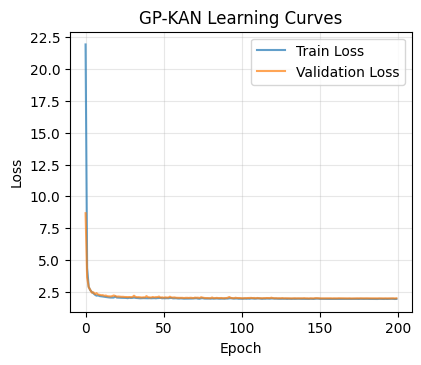

In [ ]:
# モデル評価
improved_gpkan.eval_mode()

# テストデータでの予測（バッチ処理）
test_means = []
test_vars = []

with torch.no_grad():
    for batch_x, batch_y in test_dataloader:
        test_mean, test_var = improved_gpkan.predict(batch_x)
        test_means.append(test_mean)
        test_vars.append(test_var)

test_mean = torch.cat(test_means, dim=0)
test_var = torch.cat(test_vars, dim=0)

# RMSE計算
test_rmse = torch.sqrt(torch.mean((test_mean - y_test.squeeze()) ** 2))
test_mae = torch.mean(torch.abs(test_mean - y_test.squeeze()))
test_r2 = 1 - torch.sum((y_test.squeeze() - test_mean) ** 2) / torch.sum(
    (y_test.squeeze() - y_test.mean()) ** 2
)

print(f"=== GP-KAN性能評価 ===")
print(f"Test RMSE: {test_rmse.item():.6f}")
print(f"Test MAE: {test_mae.item():.6f}")
print(f"Test R²: {test_r2.item():.6f}")
print(f"平均予測分散: {test_var.mean().item():.6f}")

# 可視化
plt.figure(figsize=(15, 8))

# 学習曲線
plt.subplot(2, 3, 1)
plt.plot(train_losses_improved, label="Train Loss", alpha=0.7)
plt.plot(val_losses_improved, label="Validation Loss", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GP-KAN Learning Curves")
plt.legend()
plt.grid(True, alpha=0.3)

print(f"\n=== 最終結果 ===")
print(f"GP-KAN Test RMSE: {test_rmse.item():.6f}")
print(f"学習時間: {training_time_improved:.2f} seconds")

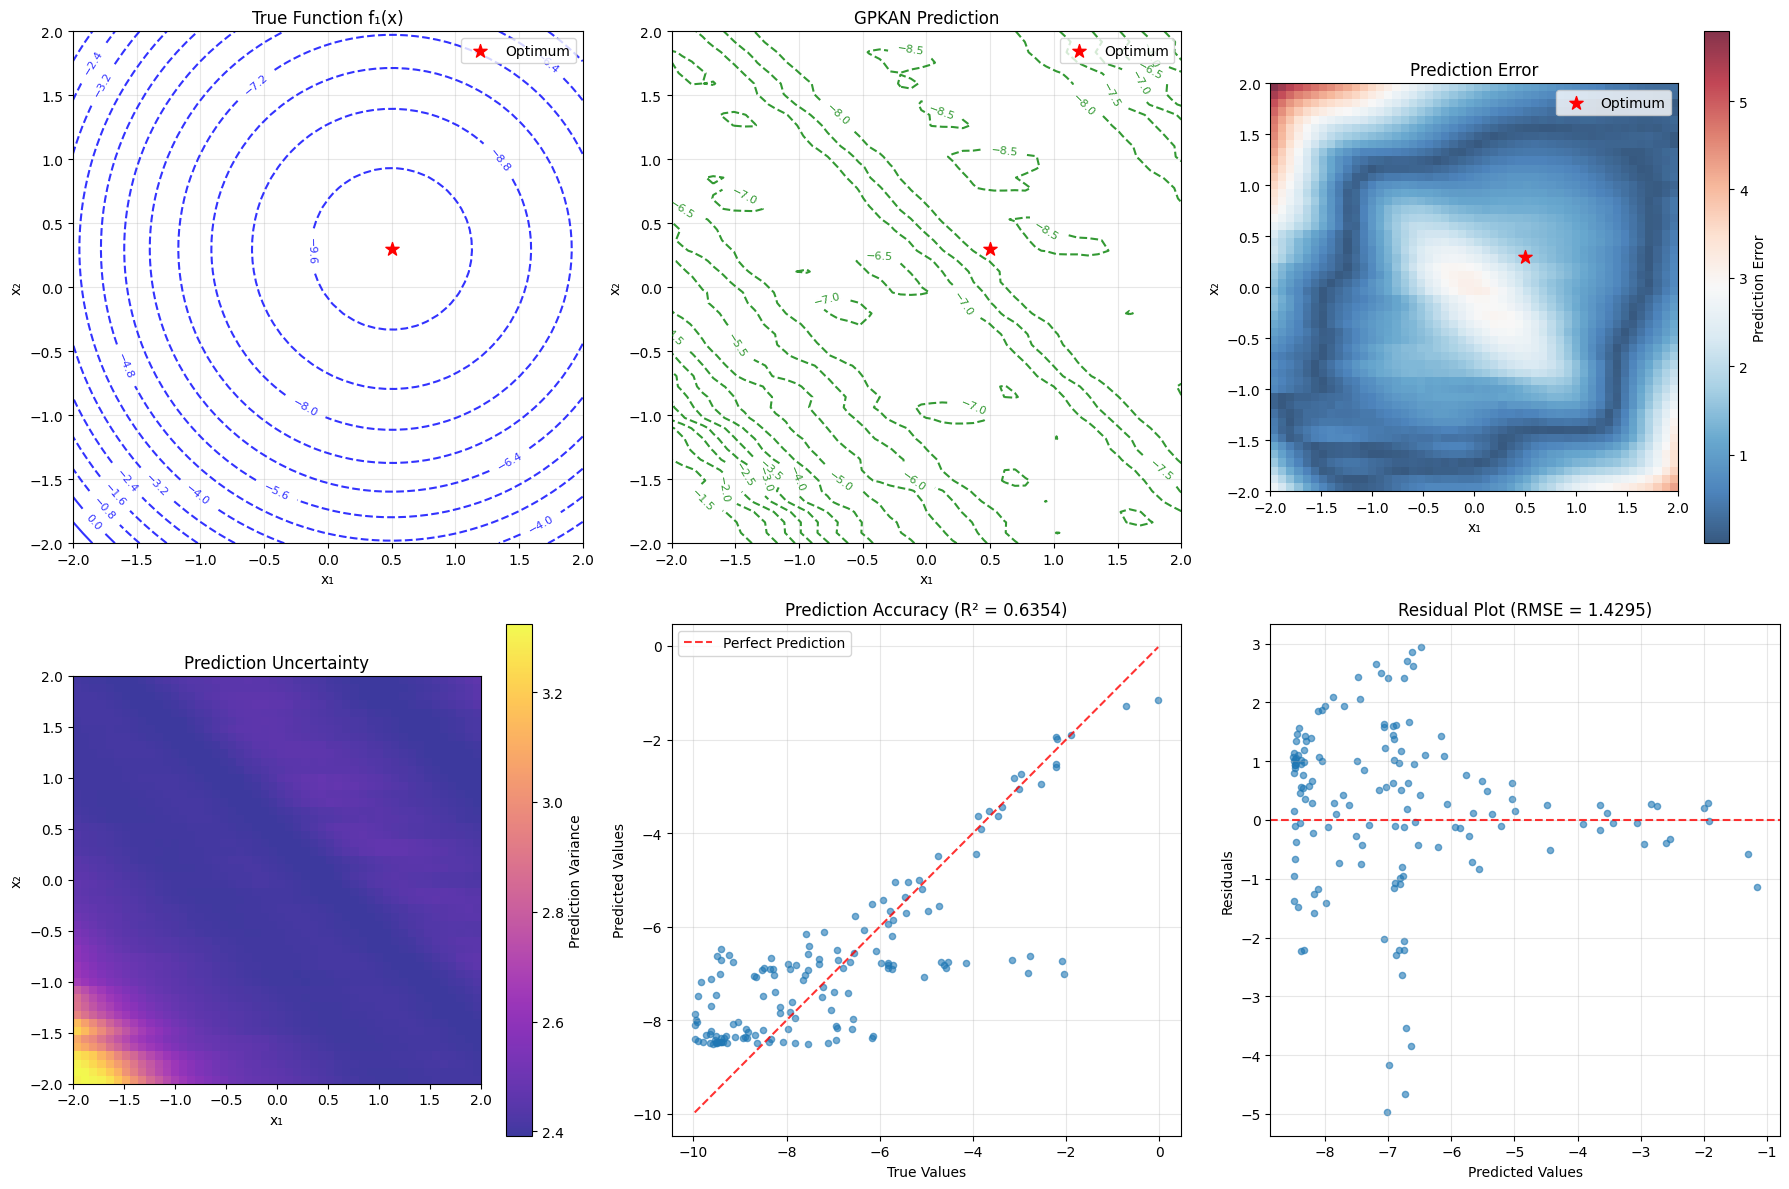

=== GPKAN近似性能サマリー ===
目標関数: f₁(x) = ||x - x_opt||² + f_opt
  x_opt = [0.5 0.3]
  f_opt = -10.0
学習データ数: 700
テストRMSE: 1.429532
テストR²: 0.635398
隠れ層誘導点数: 16
最終層誘導点数: 10


In [ ]:
# 密なグリッドでの予測と可視化
grid_density = 50
x1_dense = np.linspace(input_range[0], input_range[1], grid_density)
x2_dense = np.linspace(input_range[0], input_range[1], grid_density)
X1_dense, X2_dense = np.meshgrid(x1_dense, x2_dense)
grid_dense = torch.FloatTensor(np.column_stack([X1_dense.ravel(), X2_dense.ravel()]))

# 密なグリッドでの予測（バッチ処理）
with torch.no_grad():
    dense_means = []
    dense_vars = []

    dense_batch_size = 100
    for i in range(0, len(grid_dense), dense_batch_size):
        batch_grid = grid_dense[i : i + dense_batch_size]
        pred_mean, pred_var = improved_gpkan.predict(batch_grid)
        dense_means.append(pred_mean)
        dense_vars.append(pred_var)

    dense_mean = torch.cat(dense_means, dim=0).reshape(grid_density, grid_density)
    dense_var = torch.cat(dense_vars, dim=0).reshape(grid_density, grid_density)

# 真の関数値（密なグリッド）
true_dense = target_function(grid_dense.numpy()).reshape(grid_density, grid_density)

# 可視化（2x3のsubplotグリッド）
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 真の関数（等高線）
contour1 = axes[0, 0].contour(
    X1_dense, X2_dense, true_dense, levels=15, colors="blue", alpha=0.8
)
axes[0, 0].clabel(contour1, inline=True, fontsize=8)
axes[0, 0].scatter(
    x_opt[0], x_opt[1], c="red", s=100, marker="*", label="Optimum", zorder=5
)
axes[0, 0].set_title("True Function f₁(x)")
axes[0, 0].set_xlabel("x₁")
axes[0, 0].set_ylabel("x₂")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. DeepGP予測（等高線）
contour2 = axes[0, 1].contour(
    X1_dense, X2_dense, dense_mean.numpy(), levels=15, colors="green", alpha=0.8
)
axes[0, 1].clabel(contour2, inline=True, fontsize=8)
axes[0, 1].scatter(
    x_opt[0], x_opt[1], c="red", s=100, marker="*", label="Optimum", zorder=5
)
axes[0, 1].set_title("GPKAN Prediction")
axes[0, 1].set_xlabel("x₁")
axes[0, 1].set_ylabel("x₂")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 予測誤差
error_dense = np.abs(dense_mean.numpy() - true_dense)
im1 = axes[0, 2].imshow(
    error_dense,
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin="lower",
    cmap="RdBu_r",
    alpha=0.8,
)
axes[0, 2].scatter(
    x_opt[0], x_opt[1], c="red", s=100, marker="*", label="Optimum", zorder=5
)
plt.colorbar(im1, ax=axes[0, 2], label="Prediction Error")
axes[0, 2].set_title("Prediction Error")
axes[0, 2].set_xlabel("x₁")
axes[0, 2].set_ylabel("x₂")
axes[0, 2].legend()

# 4. 予測不確実性（分散）
im2 = axes[1, 0].imshow(
    dense_var.numpy(),
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin="lower",
    cmap="plasma",
    alpha=0.8,
)
plt.colorbar(im2, ax=axes[1, 0], label="Prediction Variance")
axes[1, 0].set_title("Prediction Uncertainty")
axes[1, 0].set_xlabel("x₁")
axes[1, 0].set_ylabel("x₂")

# 5. 散布図：真の値 vs 予測値（テストデータ）
axes[1, 1].scatter(y_test.numpy(), test_mean.numpy(), alpha=0.6, s=20)
min_val = min(y_test.min().item(), test_mean.min().item())
max_val = max(y_test.max().item(), test_mean.max().item())
axes[1, 1].plot(
    [min_val, max_val], [min_val, max_val], "r--", alpha=0.8, label="Perfect Prediction"
)
axes[1, 1].set_xlabel("True Values")
axes[1, 1].set_ylabel("Predicted Values")
axes[1, 1].set_title(f"Prediction Accuracy (R² = {test_r2.item():.4f})")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. 残差プロット
residuals = (test_mean - y_test.squeeze()).numpy()
axes[1, 2].scatter(test_mean.numpy(), residuals, alpha=0.6, s=20)
axes[1, 2].axhline(y=0, color="r", linestyle="--", alpha=0.8)
axes[1, 2].set_xlabel("Predicted Values")
axes[1, 2].set_ylabel("Residuals")
axes[1, 2].set_title(f"Residual Plot (RMSE = {test_rmse.item():.4f})")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 統計サマリー
print("=== GPKAN近似性能サマリー ===")
print(f"目標関数: f₁(x) = ||x - x_opt||² + f_opt")
print(f"  x_opt = {x_opt}")
print(f"  f_opt = {f_opt}")
print(f"学習データ数: {len(train_dataset)}")
print(f"テストRMSE: {test_rmse.item():.6f}")
print(f"テストR²: {test_r2.item():.6f}")
print(f"隠れ層誘導点数: 16")
print(f"最終層誘導点数: 10")